# Titanic Dataset Data Cleaning and Preprocessing

This notebook demonstrates the complete preprocessing pipeline for the Titanic dataset including:

- Data Exploration
- Missing Value Handling
- Feature Encoding
- Outlier Detection
- Outlier Removal
- Feature Scaling
- Dataset Export

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

plt.style.use("default")

print("Libraries Imported Successfully")

Libraries Imported Successfully


## Dataset Exploration

The dataset is loaded and inspected to understand its structure, data types, and statistical properties.

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")

print("Dataset Loaded Successfully\n")

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

df.head()

Dataset Loaded Successfully

Rows    : 891
Columns : 12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("="*60)
print("DATASET INFORMATION")
print("="*60)

df.info()

print("\n")

print("="*60)
print("STATISTICAL SUMMARY")
print("="*60)

display(df.describe())

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


STATISTICAL SUMMARY


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Missing Value Analysis

This section identifies missing values and visualizes them using a heatmap to understand data quality issues.

In [4]:
print("="*60)
print("MISSING VALUES")
print("="*60)

missing_values = df.isnull().sum()

missing_percentage = (
    df.isnull().sum()
    / len(df)
) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": round(missing_percentage,2)
})

display(
    missing_df[
        missing_df["Missing Values"] > 0
    ]
)

MISSING VALUES


,Missing Values,Percentage
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22


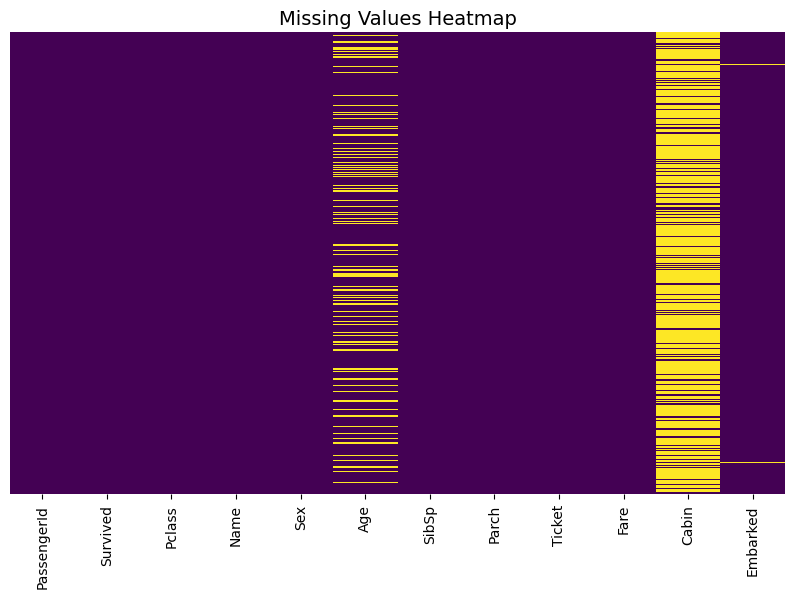

In [5]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.isnull(),
    yticklabels=False,
    cmap="viridis",
    cbar=False
)

plt.title(
    "Missing Values Heatmap",
    fontsize=14
)

plt.show()

## Missing Value Treatment

Missing values are handled using appropriate statistical techniques:

- Age → Median Imputation
- Embarked → Mode Imputation
- Cabin → Removed due to excessive missing values

In [6]:
# Age → Median Imputation

df["Age"] = df["Age"].fillna(
    df["Age"].median()
)

# Embarked → Mode Imputation

df["Embarked"] = df["Embarked"].fillna(
    df["Embarked"].mode()[0]
)

# Cabin → Remove
# 77% values missing

df.drop(
    "Cabin",
    axis=1,
    inplace=True
)

print("="*60)
print("MISSING VALUES AFTER CLEANING")
print("="*60)

print(df.isnull().sum())

MISSING VALUES AFTER CLEANING
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## Categorical Feature Encoding

Machine learning algorithms require numerical input. Therefore categorical variables are converted using One-Hot Encoding.

In [7]:
df = pd.get_dummies(
    df,
    columns=["Sex","Embarked"],
    drop_first=True,
    dtype=int
)

print("Encoding Completed Successfully\n")

df.head()

Encoding Completed Successfully



,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,1,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,0,0,1
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,1,0,1


## Outlier Detection

Outliers in the Fare feature are identified using boxplots and the Interquartile Range (IQR) method.

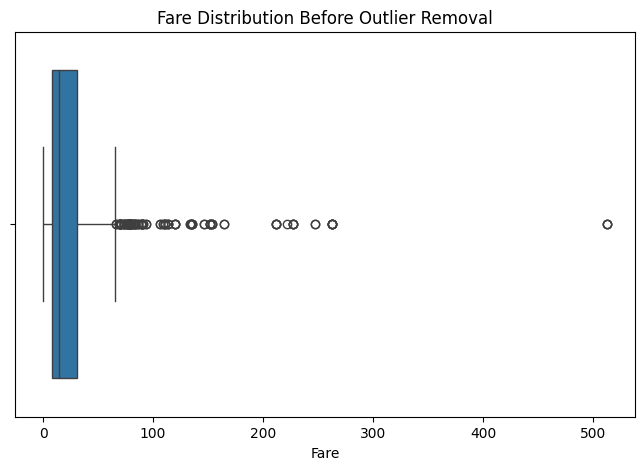

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Fare"]
)

plt.title(
    "Fare Distribution Before Outlier Removal"
)

plt.show()

In [9]:
Q1 = df["Fare"].quantile(0.25)

Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)

upper_bound = Q3 + (1.5 * IQR)

df_cleaned = df[
    (df["Fare"] >= lower_bound)
    &
    (df["Fare"] <= upper_bound)
]

print("Original Dataset Shape :", df.shape)

print(
    "Dataset Shape After Outlier Removal :",
    df_cleaned.shape
)

Original Dataset Shape : (891, 12)
Dataset Shape After Outlier Removal : (775, 12)


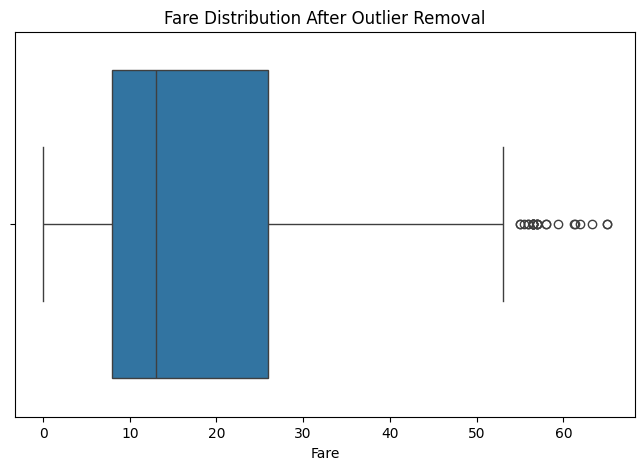

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df_cleaned["Fare"]
)

plt.title(
    "Fare Distribution After Outlier Removal"
)

plt.show()

## Feature Scaling

Numerical features are standardized using StandardScaler to bring them to a common scale.

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_cleaned = df_cleaned.copy()

df_cleaned.loc[:, ["Age", "Fare"]] = scaler.fit_transform(
    df_cleaned[["Age", "Fare"]]
)

print(
    "Feature Scaling Completed Successfully"
)

df_cleaned[
    ["Age","Fare"]
].head()

Feature Scaling Completed Successfully


,Age,Fare
0,-0.528321,-0.779117
2,-0.215182,-0.729373
3,0.489381,2.599828
4,0.489381,-0.720161
5,-0.058613,-0.690071


In [12]:
print("="*60)
print("FINAL DATASET INFORMATION")
print("="*60)

print(df_cleaned.shape)

df_cleaned.head()

FINAL DATASET INFORMATION
(775, 12)


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",-0.528321,1,0,A/5 21171,-0.779117,1,0,1
2,3,1,3,"Heikkinen, Miss. Laina",-0.215182,0,0,STON/O2. 3101282,-0.729373,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.489381,1,0,113803,2.599828,0,0,1
4,5,0,3,"Allen, Mr. William Henry",0.489381,0,0,373450,-0.720161,1,0,1
5,6,0,3,"Moran, Mr. James",-0.058613,0,0,330877,-0.690071,1,1,0


## Correlation Analysis

A correlation matrix is generated to identify relationships among numerical features after preprocessing.

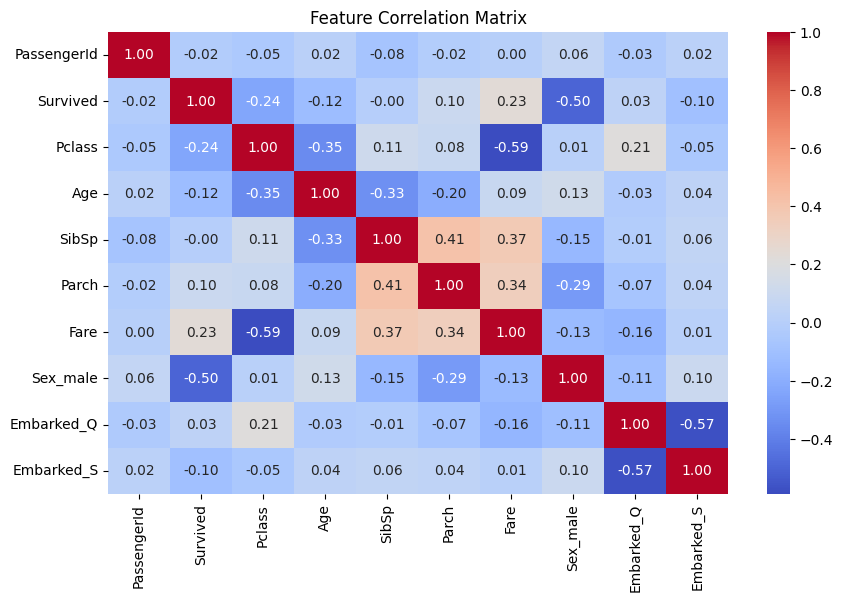

In [16]:
plt.figure(figsize=(10,6))

numeric_cols = df_cleaned.select_dtypes(
    include=np.number
)

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Feature Correlation Matrix"
)

plt.show()

In [13]:
df_cleaned.to_csv(
    "Cleaned_Titanic_Dataset.csv",
    index=False
)

print(
    "Cleaned Dataset Exported Successfully"
)

Cleaned Dataset Exported Successfully


## Final Cleaned Dataset

The final processed dataset is displayed below after all preprocessing operations have been completed.

In [14]:
print("="*70)
print("TASK 1 : DATA CLEANING & PREPROCESSING COMPLETED")
print("="*70)

print(
    f"Original Records : {df.shape[0]}"
)

print(
    f"Final Records    : {df_cleaned.shape[0]}"
)

print("\nOperations Performed")

print("✓ Dataset Exploration")
print("✓ Missing Value Analysis")
print("✓ Missing Value Treatment")
print("✓ Categorical Encoding")
print("✓ Outlier Detection")
print("✓ Outlier Removal")
print("✓ Feature Scaling")
print("✓ Dataset Export")

TASK 1 : DATA CLEANING & PREPROCESSING COMPLETED
Original Records : 891
Final Records    : 775

Operations Performed
✓ Dataset Exploration
✓ Missing Value Analysis
✓ Missing Value Treatment
✓ Categorical Encoding
✓ Outlier Detection
✓ Outlier Removal
✓ Feature Scaling
✓ Dataset Export


# Conclusion

The Titanic dataset was successfully preprocessed through:

✅ Missing Value Handling

✅ Categorical Feature Encoding

✅ Outlier Detection and Removal

✅ Feature Scaling

✅ Correlation Analysis

✅ Dataset Export

Final Dataset Shape: 775 Rows × 12 Columns

The cleaned dataset is now ready for machine learning model development and predictive analysis.